## Cardenas Basalt ca. 1082 Ma paleomagnetic pole

### Geologic context

The ca. 1082 Ma Cardenas Basalt a pulse of mafic magmatic activity in southwestern Laurentia that is particularly well exposed in the Grand Canyon and is likely associated with intrusive activity in the Grand Canyon as well as in the Dead Mountains, California. The Cardenas magmatism is also temporally coincident with some late stage magmatism within the Midcontinent Rift in the Lake Superior area.

Although Weil et al., 2003 first reported paleomagnetic data from three Cardenas Basalt lava flows in the Grand Canyon, these data were interpreted to be coeval with the thick mafic intrusions in the Unkar Group sedimentary rocks that also outcrop in the Grand Canyon, some in vicinity of the Cardenas lava flows. The Cardenas lava flows were not dated at the time, and the paleomagnetic data were not reported in context of volcanostratigraphy. 

Zhang et al. (2024) recently reported new paleomagnetic data from three documented stratigraphic sections at Basalt Canyon, Lava Chuar Canyon, and Nankoweap Canyon. A total of 18 lava flows were sampled, including the Cardenas Basalt lava flow CB3, which was dated at 1082.18 ± 1.25 Ma by Mohr et al. (2024). The zircon geochronology data reported in Mohr et al. (2024) also suggest that the Cardenas Basalt is distinct and ~16 million years younger than the thick Unkar mafic sills such as the Hotauta Canyon and Stone Creek Canyon sill that are dated to be ca. 1098 Ma. Although there are mafic dikes near the Cardenas lava flows, they are not yet dated with high precision and their temporal relationship to the Cardenas lava flows is not yet clear. Therefore here we report the ca. 1082 Ma well dated Cardenas lava flow pole from Zhang et al., 2024 as the most robust paleomagnetic pole for the Cardenas Basalt.

Ding et al. (2025) present new paleomagnetic data from 9 ca. 1082 Ma mafic dikes in the Beartooth Mountains of the Wyoming craton and one mafic sheet (Calder) from the Slave craton. The Wyoming dikes are fine- to medium-grained diabase (clinopyroxene, orthopyroxene, plagioclase, minor biotite, hornblende, and interstitial granophyre) trending west-east to WNW-ESE with widths of 1–20 m. 

### Paleomagnetic and rock magnetic data

Thermal demagnetization data is consistent with remanence being dominantly held by low-titanium magnetite, maghemite, and (titano) hematite.

All samples were subjected to stepwise thermal demagnetization. High-temperature components (HTC) were isolated between 500–580°C, directed west with moderate inclinations.

There is no paleomagnetic field tests on the Cardenas lava flow pole, but the pole is consistent with the expected position of the ca. 1082 Ma pole based on the apparent polar wander path for Laurentia. Pole longitude=183.9°E, pole latitude=15.9°N, A95 =7.4°, N=18. This pole passes the Deenen et al. (2011) criteria (A95_min = 3.8°, A95_max = 13.3°) and fulfills  of the seven Meert et al. (2020) quality criteria.


### Age constraints

- Cardenas lava flow CB3: 1082.18 ± 1.25 Ma (U-Pb zircon; Mohr et al., 2024)

### References

#### Paleomagnetism

- Zhang, Y., Anderson, N. S., Mohr, M. T., Nelson, L. L., Macdonald, F. A., Schmitz, M. D., Thurston, O. G., Guenthner, W. R., Karlstrom, K. E., & Swanson-Hysell, N. L. (2024). Paleomagnetic records from pulsed magmatism in the southwestern Laurentia large igneous province and Cardenas Basalt support rapid late Mesoproterozoic plate motion. Journal of Geophysical Research: Solid Earth, 129(10). https://doi.org/10.1029/2024jb029036


#### Geochronology

- Mohr, M. T., Schmitz, M. D., Swanson-Hysell, N. L., Karlstrom, K. E., Macdonald, F. A., Holland, M. E., Zhang, Y., & Anderson, N. S. (2024). High-precision U-Pb geochronology links magmatism in the southwestern Laurentia large igneous province and Midcontinent Rift. Geology. https://doi.org/10.1130/g51786.1

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pmagpy.contribution_builder as cb
import pandas as pd
import numpy as np

%config InlineBackend.figure_format='retina'
%matplotlib inline

## import the MagIC contribution

In [2]:
# set the directory path (dir_path) to the data
dir_path = '../data/1082_Cardenas'

# set the name of the MagIC file
ipmag.unpack_magic('magic_contribution_20009.txt', 
                     dir_path = dir_path,
                     input_dir_path = dir_path, print_progress=False)

1  records written to file  /Users/yimingzhang/Github/2026_Laurentia_Precambrian_poles/data/1082_Cardenas/contribution.txt
2  records written to file  /Users/yimingzhang/Github/2026_Laurentia_Precambrian_poles/data/1082_Cardenas/locations.txt
200  records written to file  /Users/yimingzhang/Github/2026_Laurentia_Precambrian_poles/data/1082_Cardenas/sites.txt
314  records written to file  /Users/yimingzhang/Github/2026_Laurentia_Precambrian_poles/data/1082_Cardenas/samples.txt
2217  records written to file  /Users/yimingzhang/Github/2026_Laurentia_Precambrian_poles/data/1082_Cardenas/specimens.txt
11331  records written to file  /Users/yimingzhang/Github/2026_Laurentia_Precambrian_poles/data/1082_Cardenas/measurements.txt


True

### Site-level, and specimen-level data

In [3]:
sites_geo, sites_tc = pt.load_magic_sites('../data/1082_Cardenas/sites.txt')
print(f'{len(sites_tc)} sites loaded')
sites_tc[['site', 'lat', 'lon',
          'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95',
          'vgp_lat', 'vgp_lon', 'vgp_dp', 'vgp_dm', 'dir_tilt_correction', 'dir_n_samples']]

specimens_data = pd.read_csv('../data/1082_Cardenas/specimens.txt', header = 1, sep='\t')
specimens_data['site'] = specimens_data['specimen'].str.split('-').str[0]

# map lat lon from sites to specimens 
specimens_data = specimens_data.merge(sites_tc[['site', 'lat', 'lon']], on='site', how='left')

# get the Cardenas sites and filter out the Unkar sites
CB_site_data = sites_tc[sites_tc['site'].str.contains('CB')].reset_index(drop=1)
CB_site_data['rock type'] = 'lava flow'

# get mid temp component in tilt-corrected coordinates
CB_site_data_mt_tc = CB_site_data[(CB_site_data['dir_tilt_correction'] == 100) & (CB_site_data['dir_comp_name'] == 'mt')]

# get maghemite temp component in tilt-corrected coordinates
CB_site_data_mht_tc = CB_site_data[(CB_site_data['dir_tilt_correction'] == 100) & (CB_site_data['dir_comp_name'] == 'mht')]

# get high temp component in tilt-corrected coordinates
CB_site_data_ht_tc = CB_site_data[(CB_site_data['dir_tilt_correction'] == 100) & (CB_site_data['dir_comp_name'] == 'ht')]

CB_specimen_data = specimens_data[specimens_data['site'].str.contains('CB')].reset_index(drop=1)
CB_specimen_data_mt_tc = CB_specimen_data[(CB_specimen_data['dir_tilt_correction'] == 100) & (CB_specimen_data['dir_comp'] == 'mt')]
CB_specimen_data_mht_tc = CB_specimen_data[(CB_specimen_data['dir_tilt_correction'] == 100) & (CB_specimen_data['dir_comp'] == 'mht')]
CB_specimen_data_ht_tc = CB_specimen_data[(CB_specimen_data['dir_tilt_correction'] == 100) & (CB_specimen_data['dir_comp'] == 'ht')]

CB4_site_data_mht_tc = CB_site_data_mht_tc
CB4_site_ht_tc = CB_site_data_ht_tc[CB_site_data_ht_tc['site'] == 'CB4']

CB4_specimen_ht_tc = CB_specimen_data_ht_tc[CB_specimen_data_ht_tc['site'] == 'CB4']
CB4_specimen_mht_tc = CB_specimen_data_mht_tc[CB_specimen_data_mht_tc['site'] == 'CB4']
CB4_specimen_mt_tc = CB_specimen_data_mt_tc[CB_specimen_data_mt_tc['site'] == 'CB4']

CB4_directions_tc = pd.concat([CB4_specimen_ht_tc, CB4_specimen_mt_tc])
CB4_mean_dir_tc = ipmag.fisher_mean(CB4_directions_tc['dir_dec'].tolist(), CB4_directions_tc['dir_inc'].tolist())

CB4_vgps_tc = np.array([pmag.dia_vgp(CB4_directions_tc['dir_dec'].tolist()[i], 
                                  CB4_directions_tc['dir_inc'].tolist()[i], 
                                  0, 
                                  CB4_site_data_mht_tc['lat'].tolist()[0], 
                                  CB4_site_data_mht_tc['lon'].tolist()[0]) for i in range(CB4_directions_tc.shape[0])]).T[:2]

CB4_dpdm_tc = pmag.dia_vgp(CB4_mean_dir_tc['dec'], 
                        CB4_mean_dir_tc['inc'], 
                        CB4_mean_dir_tc['alpha95'], 
                        CB4_site_data_mht_tc['lat'].tolist()[0], 
                        CB4_site_data_mht_tc['lon'].tolist()[0])
CB4_mean_pole_tc = ipmag.fisher_mean(CB4_vgps_tc[0], CB4_vgps_tc[1])

CB_Nankoweap_tc = CB_site_data_mt_tc[CB_site_data_mt_tc['site'].isin(['CB1','CB2','CB3','CB5'])]

CB_Nankoweap_tc = pd.concat([ CB_Nankoweap_tc, pd.DataFrame([ { 'site': 'CB4',
                            'location':                                                       'Grand Canyon',
                            'samples':                    'CB4-2:CB4-3:CB4-4:CB4-5:CB4-6:CB4-7:CB4-8',
                            'specimens':           'CB4-2a:CB4-3a:CB4-4a:CB4-5a:CB4-6a:CB4-7a:CB4-8a',
                            'dir_alpha95':                                   round(CB4_mean_dir_tc['alpha95'],1),
                            'dir_comp_name':                                                            'mt',
                            'dir_dec':                                                              round(CB4_mean_dir_tc['dec'],1),
                            'dir_inc':                                                              round(CB4_mean_dir_tc['inc'],1),
                            'dir_k':                                                                round(CB4_mean_dir_tc['k'],1),
                            'dir_n_samples':                                                        7,
                            'dir_n_specimens':                                                      7,
                            'dir_n_specimens_lines':                                                7,
                            'dir_n_specimens_planes':                                               0,
                            'dir_polarity':                                                              't',
                            'dir_r':                                                                round(CB4_mean_dir_tc['r'],1),
                            'dir_tilt_correction':                                                     100,
                            'lat':                                                                   CB4_site_data_mht_tc['lat'].tolist()[0],
                            'lon':                                                                  CB4_site_data_mht_tc['lon'].tolist()[0],
                            'analysts':                                                                'NaN',
                            'criteria':                                                             'ACCEPT',
                            'software_packages':                          'pmagpy-4.2.24-1: demag_gui.v.3.0',
                            'citations':                                                        'This study',
                            'method_codes':              'LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO',
                            'result_quality':                                                            'g',
                            'vgp_dm':                                                                  CB4_dpdm_tc[2],
                            'vgp_dp':                                                                  CB4_dpdm_tc[3],
                            'vgp_lat':                                                                CB4_mean_pole_tc['inc'],
                            'vgp_lon':                                                               CB4_mean_pole_tc['dec'], 
                            'rock type':                                                                'lava flow'}], index=[0])])
CB_Lava_Chuar_mt_tc = CB_site_data_mt_tc[CB_site_data_mt_tc['site'].isin(['CB6','CB7'])]

CBS1_site_data_mt_tc = CB_site_data_mt_tc[CB_site_data_mt_tc['site'] == 'CBS1']

CBS1_site_data_ht_tc = CB_site_data_ht_tc[CB_site_data_ht_tc['site'] == 'CBS1']
CB11_site_data_mt_tc = CB_site_data_mt_tc[CB_site_data_mt_tc['site'] == 'CB11']

CBS1_specimen_data_ht_tc = CB_specimen_data_ht_tc[CB_specimen_data_ht_tc['site'] == 'CBS1']
CB11_specimen_data_mt_tc = CB_specimen_data_mt_tc[CB_specimen_data_mt_tc['site'] == 'CB11']


# tilt corrected coordinates data combination
CB11_CBS1_tc = pd.concat([CB11_specimen_data_mt_tc, CBS1_specimen_data_ht_tc])
CB11_CSB1_mean_dir_tc = ipmag.fisher_mean(CB11_CBS1_tc.dir_dec.tolist(), CB11_CBS1_tc.dir_inc.tolist())
CB11_CSB1_vgps_tc = np.array([pmag.dia_vgp(CB11_CBS1_tc['dir_dec'].tolist()[i], 
                                  CB11_CBS1_tc['dir_inc'].tolist()[i], 
                                  0, 
                                  CB11_CBS1_tc['lat'].tolist()[0], 
                                  CB11_CBS1_tc['lon'].tolist()[0]) for i in range(CB11_CBS1_tc.shape[0])]).T[:2]
CB11_CSB1_dpdm_tc = pmag.dia_vgp(CB11_CSB1_mean_dir_tc['dec'], 
                        CB11_CSB1_mean_dir_tc['inc'], 
                        CB11_CSB1_mean_dir_tc['alpha95'], 
                        CB11_CBS1_tc['lat'].tolist()[0], 
                        CB11_CBS1_tc['lon'].tolist()[0])
CB11_CSB1_mean_pole_tc = ipmag.fisher_mean(CB11_CSB1_vgps_tc[0], CB11_CSB1_vgps_tc[1])

CB_Basalt_Canyon_tc = CB_site_data_mt_tc[CB_site_data_mt_tc['site'].isin(['CB8','CB9', 'CB10', 'CB12', 'CB13', 'CB14', 'CB15', 'CB16', 'CB17', 'CB18'])] 
CB_Basalt_Canyon_tc = pd.concat([CB_Basalt_Canyon_tc, pd.DataFrame([ { 'site': 'CB11-CBS1',
                            'location':                                                       'Grand Canyon',
                            'samples':             'CB11-2:CB11-4:CB11-5:CB11-6:CB11-2-7:CB11-8:CBS1-1:CBS1-2:CBS1-3:CBS1-4:CBS1-5:CBS1-6:CBS1-7:CBS1-8',
                            'specimens':           'CB11-2a:CB11-4a:CB11-5a:CB11-6a:CB11-2-7a:CB11-8a:CBS1-1a:CBS1-2a:CBS1-3a:CBS1-4a:CBS1-5a:CBS1-6a:CBS1-7a:CBS1-8a',
                            'dir_alpha95':                                   round(CB11_CSB1_mean_dir_tc['alpha95'],1),
                            'dir_comp_name':                                                            'mt',
                            'dir_dec':                                                              round(CB11_CSB1_mean_dir_tc['dec'],1),
                            'dir_inc':                                                              round(CB11_CSB1_mean_dir_tc['inc'],1),
                            'dir_k':                                                                round(CB11_CSB1_mean_dir_tc['k'],1),
                            'dir_n_samples':                                                        13,
                            'dir_n_specimens':                                                      13,
                            'dir_n_specimens_lines':                                                13,
                            'dir_n_specimens_planes':                                               0,
                            'dir_polarity':                                                              't',
                            'dir_r':                                                                round(CB11_CSB1_mean_dir_tc['r'],1),
                            'dir_tilt_correction':                                                     100,
                            'lat':                                                                   CB11_CBS1_tc['lat'].tolist()[0],
                            'lon':                                                                   CB11_CBS1_tc['lon'].tolist()[0],
                            'analysts':                                                                'NaN',
                            'criteria':                                                             'ACCEPT',
                            'software_packages':                          'pmagpy-4.2.24-1: demag_gui.v.3.0',
                            'citations':                                                        'This study',
                            'method_codes':              'LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO',
                            'result_quality':                                                            'g',
                            'vgp_dm':                                                                  CB11_CSB1_dpdm_tc[2],
                            'vgp_dp':                                                                  CB11_CSB1_dpdm_tc[3],
                            'vgp_lat':                                                                CB11_CSB1_mean_pole_tc['inc'],
                            'vgp_lon':                                                                CB11_CSB1_mean_pole_tc['dec'], 
                            'rock type':                                                                'lava flow: sediments'}], index=[0])])

Cardenas_Basalt_all = pd.concat([CB_Nankoweap_tc,CB_Lava_Chuar_mt_tc, CB_Basalt_Canyon_tc])
Cardenas_Basalt_all_mean_dir_tc = ipmag.fisher_mean(Cardenas_Basalt_all.dir_dec.tolist(), Cardenas_Basalt_all.dir_inc.tolist())
Cardenas_Basalt_all_mean_pole = ipmag.fisher_mean(Cardenas_Basalt_all.vgp_lon.tolist(), Cardenas_Basalt_all.vgp_lat.tolist())
Cardenas_Basalt_all_mean_pole

100 sites loaded


{'dec': 183.9201365297194,
 'inc': 15.934944694473888,
 'n': 18,
 'r': 17.25133015447107,
 'k': 22.70693831403029,
 'alpha95': 7.415071700086885,
 'csd': 16.99830935627096}

## Site location map

In [4]:
pt.plot_site_map(CB_site_data)

### Mean pole from VGPs

Plon: 183.9  Plat: 15.9
Number of directions in mean (n): 18
Angular radius of 95% confidence (A_95): 7.4
Precision parameter (k) estimate: 22.7


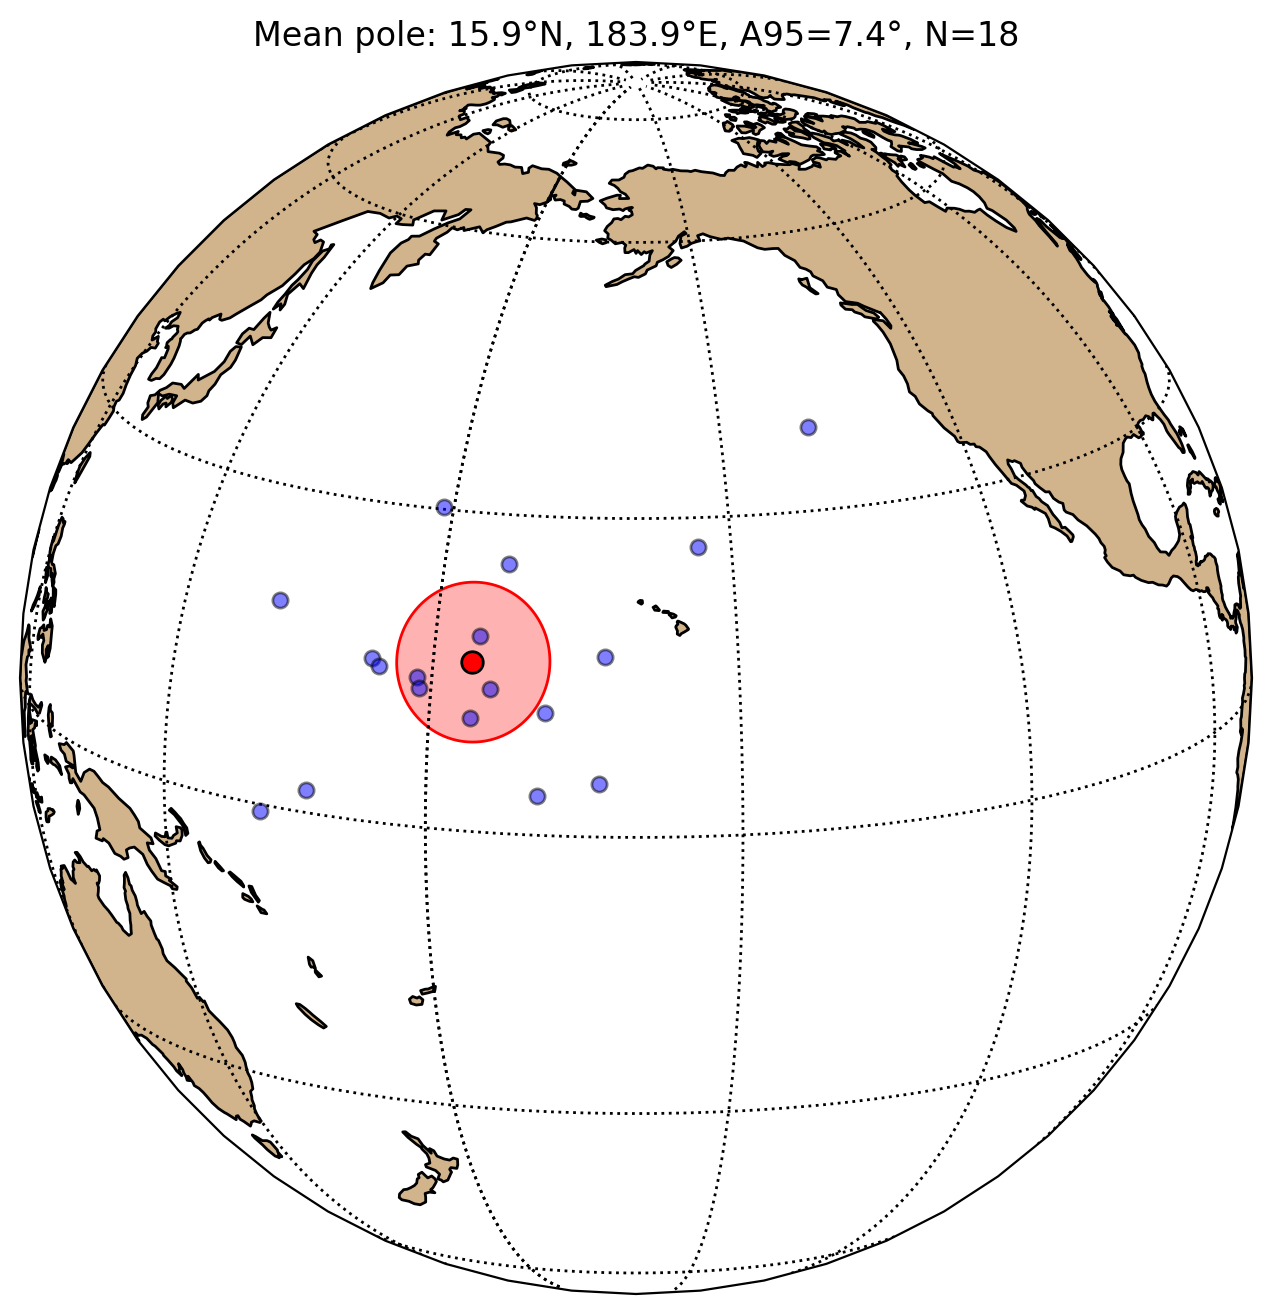

In [5]:
vgp_block, pole_mean = pt.compute_mean_pole(Cardenas_Basalt_all)
ipmag.print_pole_mean(pole_mean)
pole_plot = pt.plot_vgps_and_pole(vgp_block, pole_mean, 200, 15)

### Site directions (as measured at site)

Dec: 268.5  Inc: 46.4
Number of directions in mean (n): 18
Angular radius of 95% confidence (a_95): 7.9
Precision parameter (k) estimate: 20.2


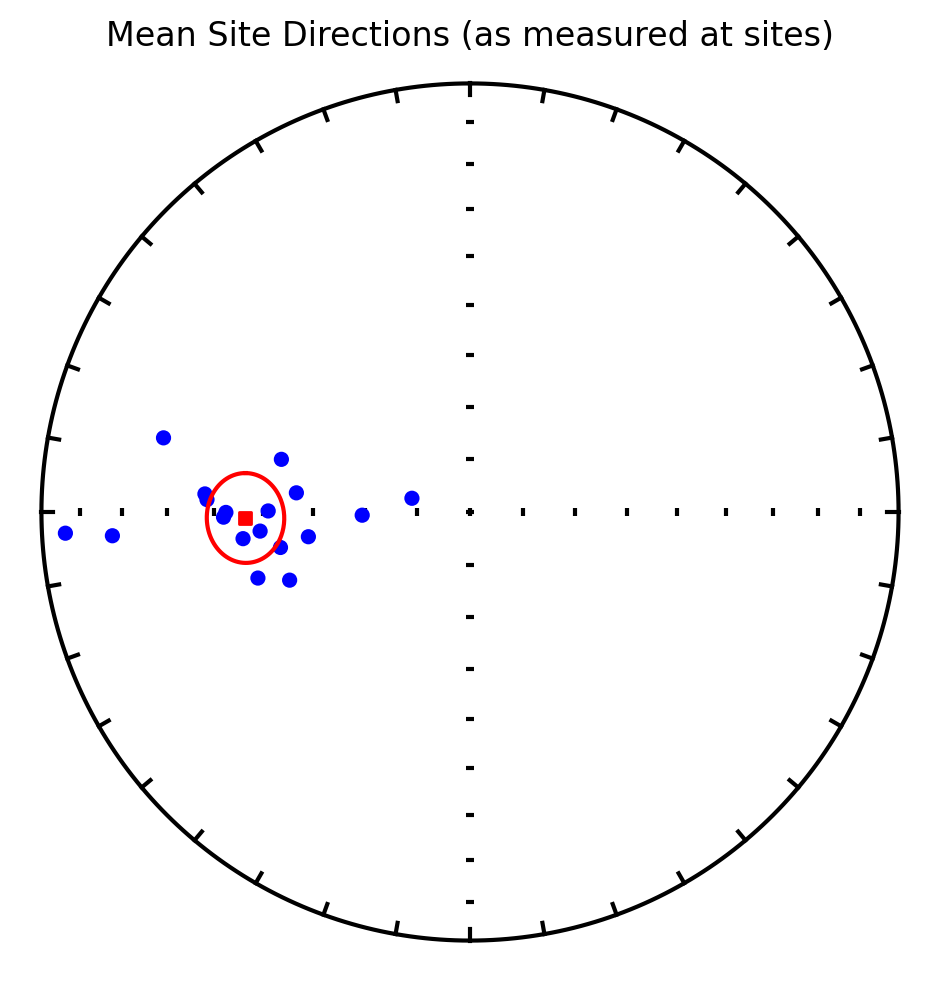

In [6]:
dir_block, dir_mean = pt.compute_mean_direction(Cardenas_Basalt_all)

ipmag.print_direction_mean(dir_mean)

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], 
                   color='red', marker='s')
ipmag.plt.title('Mean Site Directions (as measured at sites)')
ipmag.plt.show()

### Site direction (calculated from VGPS for common site location)

We will unite to the 36.283889ºN and 248.108056ºE (site CB1)

In [7]:
Cardenas_Basalt_all

,age,age_high,age_low,age_unit,citations,dir_alpha95,dir_comp_name,dir_dec,dir_inc,dir_k,...,software_packages,specimens,vgp_dm,vgp_dp,vgp_lat,vgp_lon,rock type,dir_n_specimens_planes,analysts,criteria
2,1082.18,1083.43,1080.93,Ma,This study,3.9,mt,270.3,51.1,200.0,...,pmagpy-4.2.24-1: demag_gui.v.3.0,CB1-1a:CB1-2a:CB1-3a:CB1-4a:CB1-5a:CB1-6a:CB1-...,5.300000,3.600000,18.400000,184.500000,lava flow,NaN,NaN,NaN
25,1082.18,1083.43,1080.93,Ma,This study,3.1,mt,283.3,78.7,329.0,...,pmagpy-4.2.24-1: demag_gui.v.3.0,CB2-1a:CB2-2a:CB2-3a:CB2-4a:CB2-5a:CB2-6a:CB2-...,5.900000,5.600000,38.200000,220.800000,lava flow,NaN,NaN,NaN
28,1082.18,1083.43,1080.93,Ma,This study,8.1,mt,249.3,52.9,56.0,...,pmagpy-4.2.24-1: demag_gui.v.3.0,CB3-1a:CB3-2a:CB3-3a:CB3-4a:CB3-6a:CB3-7a:CB3-8a,11.200000,7.700000,5.100000,196.500000,lava flow,NaN,NaN,NaN
35,1082.18,1083.43,1080.93,Ma,This study,6.2,mt,276.3,56.5,71.0,...,pmagpy-4.2.24-1: demag_gui.v.3.0,CB5-1a:CB5-2a:CB5-3a:CB5-4a:CB5-5a:CB5-6a:CB5-...,9.000000,6.500000,25.300000,186.800000,lava flow,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,This study,4.3,mt,261.3,58.7,41.8,...,pmagpy-4.2.24-1: demag_gui.v.3.0,CB4-2a:CB4-3a:CB4-4a:CB4-5a:CB4-6a:CB4-7a:CB4-8a,4.715935,6.344613,16.915483,196.937895,lava flow,0.0,NaN,ACCEPT
38,1082.18,1083.43,1080.93,Ma,This study,5.9,mt,252.7,47.0,88.0,...,pmagpy-4.2.24-1: demag_gui.v.3.0,CB6-1a:CB6-2a:CB6-3a:CB6-4a:CB6-5a:CB6-6a:CB6-...,7.600000,4.900000,3.800000,190.700000,lava flow,NaN,NaN,NaN
41,1082.18,1083.43,1080.93,Ma,This study,5.4,mt,269.9,42.5,106.0,...,pmagpy-4.2.24-1: demag_gui.v.3.0,CB7-1a:CB7-2a:CB7-3a:CB7-4a:CB7-5a:CB7-6a:CB7-...,6.700000,4.100000,14.100000,178.500000,lava flow,NaN,NaN,NaN
4,1082.18,1083.43,1080.93,Ma,This study,6.5,mt,273.9,38.0,88.0,...,pmagpy-4.2.24-1: demag_gui.v.3.0,CB10-1a:CB10-2a:CB10-4a:CB10-5a:CB10-6a:CB10-7...,7.700000,4.500000,15.400000,173.600000,lava flow,NaN,NaN,NaN
9,1082.18,1083.43,1080.93,Ma,This study,4.0,mt,268.8,42.0,193.0,...,pmagpy-4.2.24-1: demag_gui.v.3.0,CB12-1a:CB12-2a:CB12-3a:CB12-4a:CB12-5a:CB12-6...,4.900000,3.000000,13.100000,178.800000,lava flow,NaN,NaN,NaN
11,1082.18,1083.43,1080.93,Ma,This study,5.9,mt,267.0,6.1,107.0,...,pmagpy-4.2.24-1: demag_gui.v.3.0,CB13-1a:CB13-2a:CB13-3a:CB13-4a:CB13-5a:CB13-6...,5.900000,3.000000,-0.600000,162.400000,lava flow,NaN,NaN,NaN


Dec: 268.4  Inc: 46.5
Number of directions in mean (n): 18
Angular radius of 95% confidence (a_95): 7.9
Precision parameter (k) estimate: 20.0


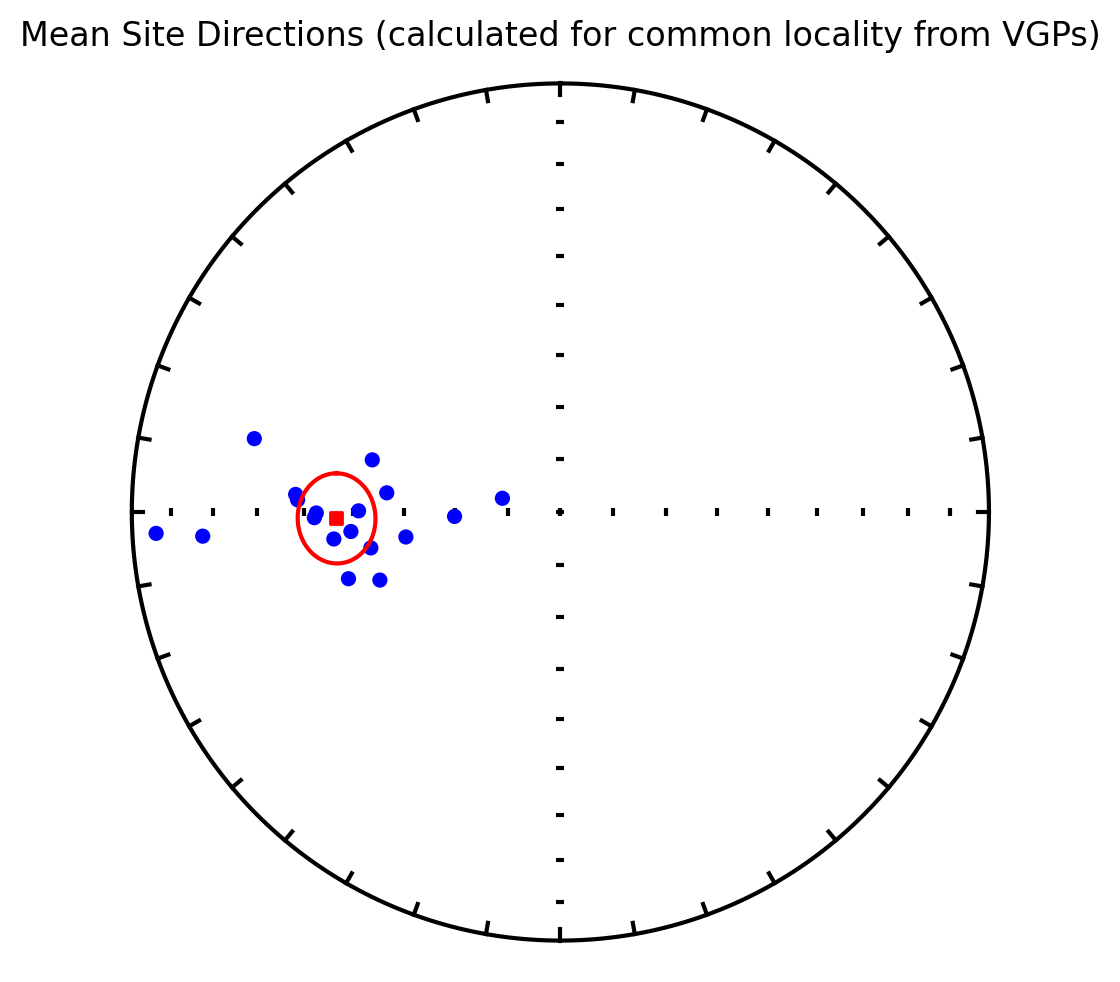

In [8]:
study_lon = 248.108056
study_lat = 36.283889
dir_block_from_vgps, dir_mean_from_vgps = pt.compute_mean_direction_from_vgps(Cardenas_Basalt_all, study_lon, study_lat)

ipmag.print_direction_mean(dir_mean_from_vgps)

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block_from_vgps, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean_from_vgps['dec'], dir_mean_from_vgps['inc'], 
                   dir_mean_from_vgps['alpha95'], color='red', marker='s')
ipmag.plt.title('Mean Site Directions (calculated for common locality from VGPs)')
ipmag.plt.show()

### Pole in the context of the Laurentia APWP

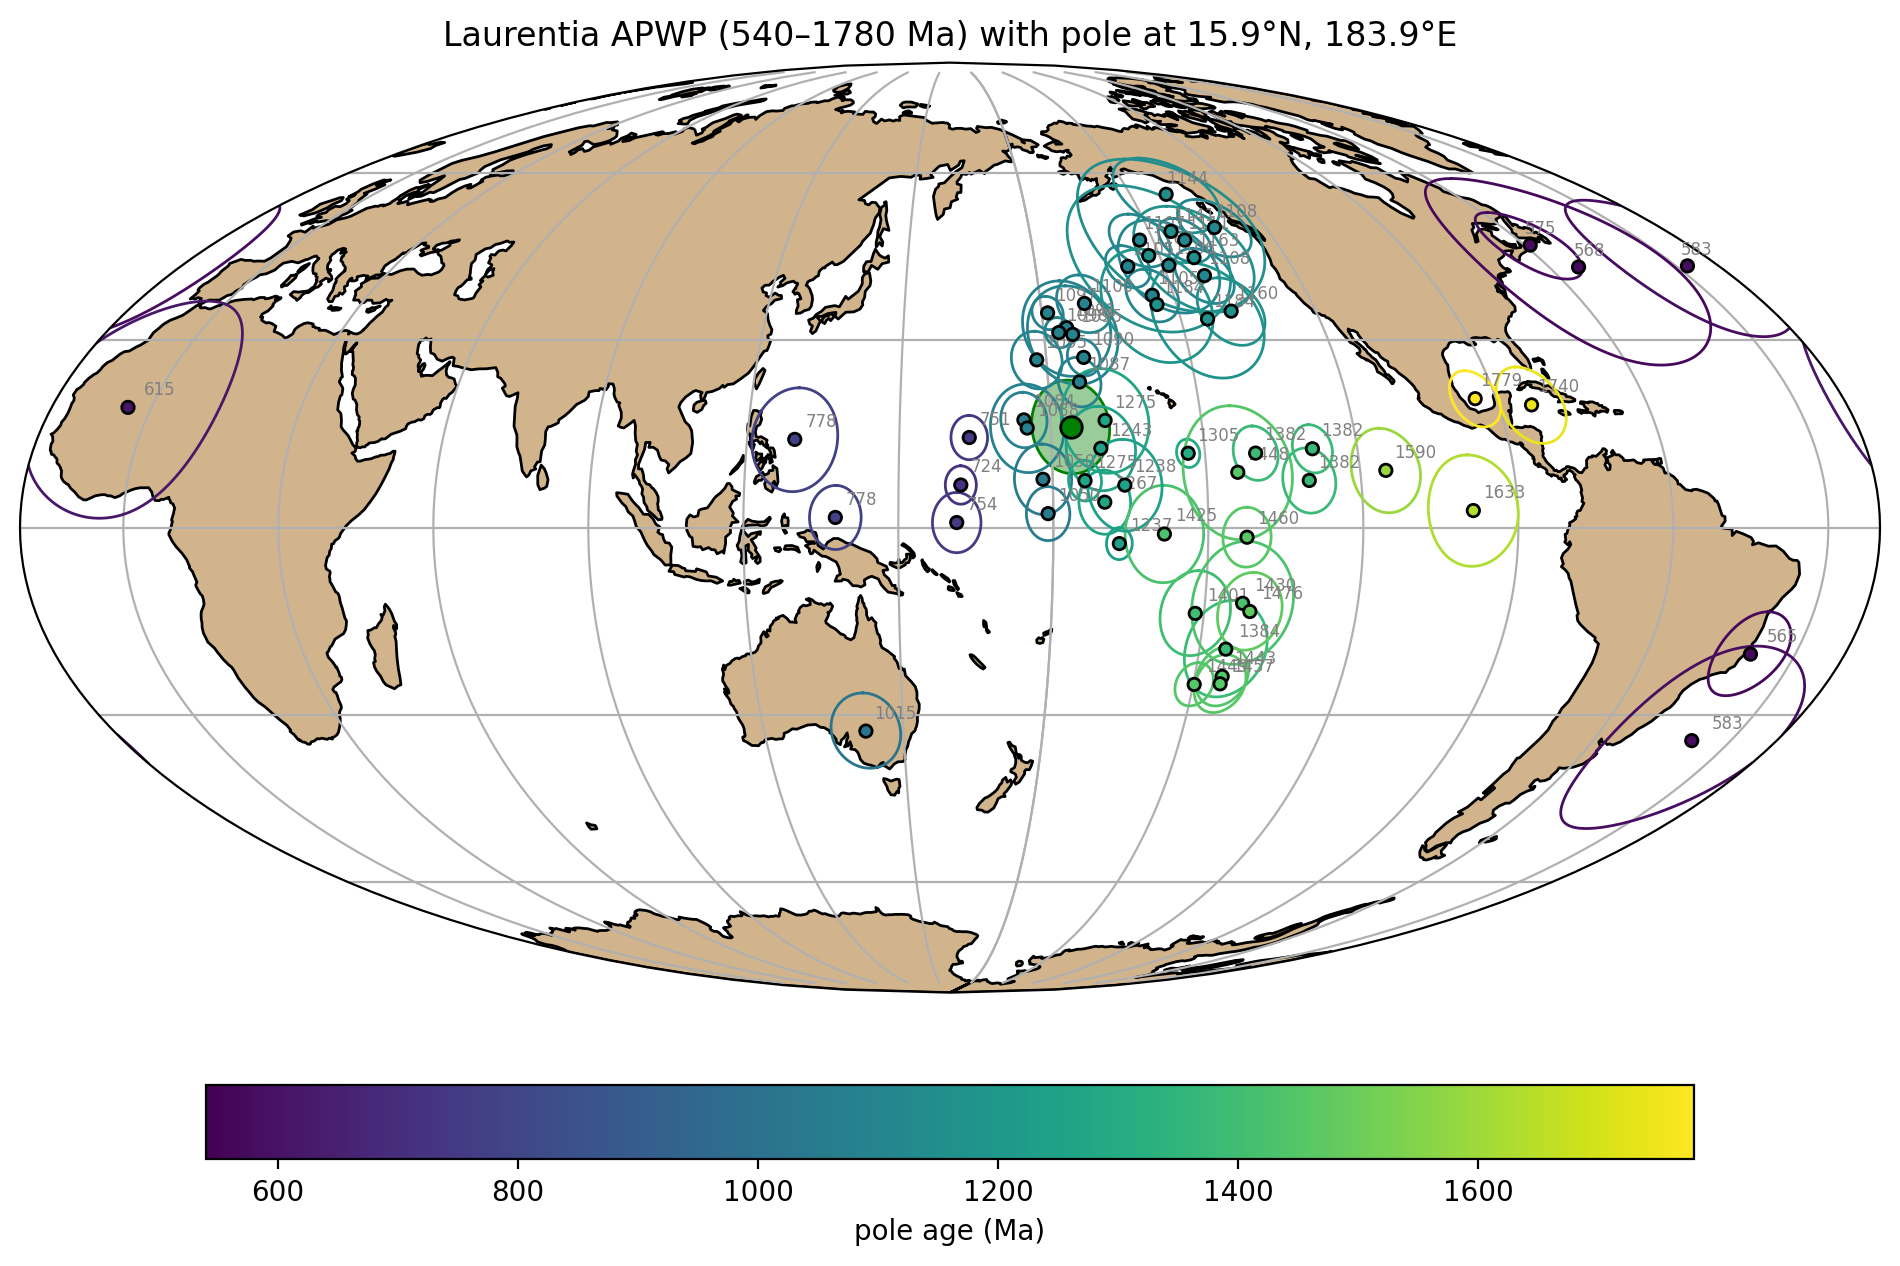

In [9]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_poles = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'], pole_mean['alpha95'])

### R2: Deenen test

In [10]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])

A_95 of 7.4 passes Deenen et al. (2011) criteria of being between 3.8 and 13.3 for this number of sites


### R7: Comparison with younger Laurentia poles

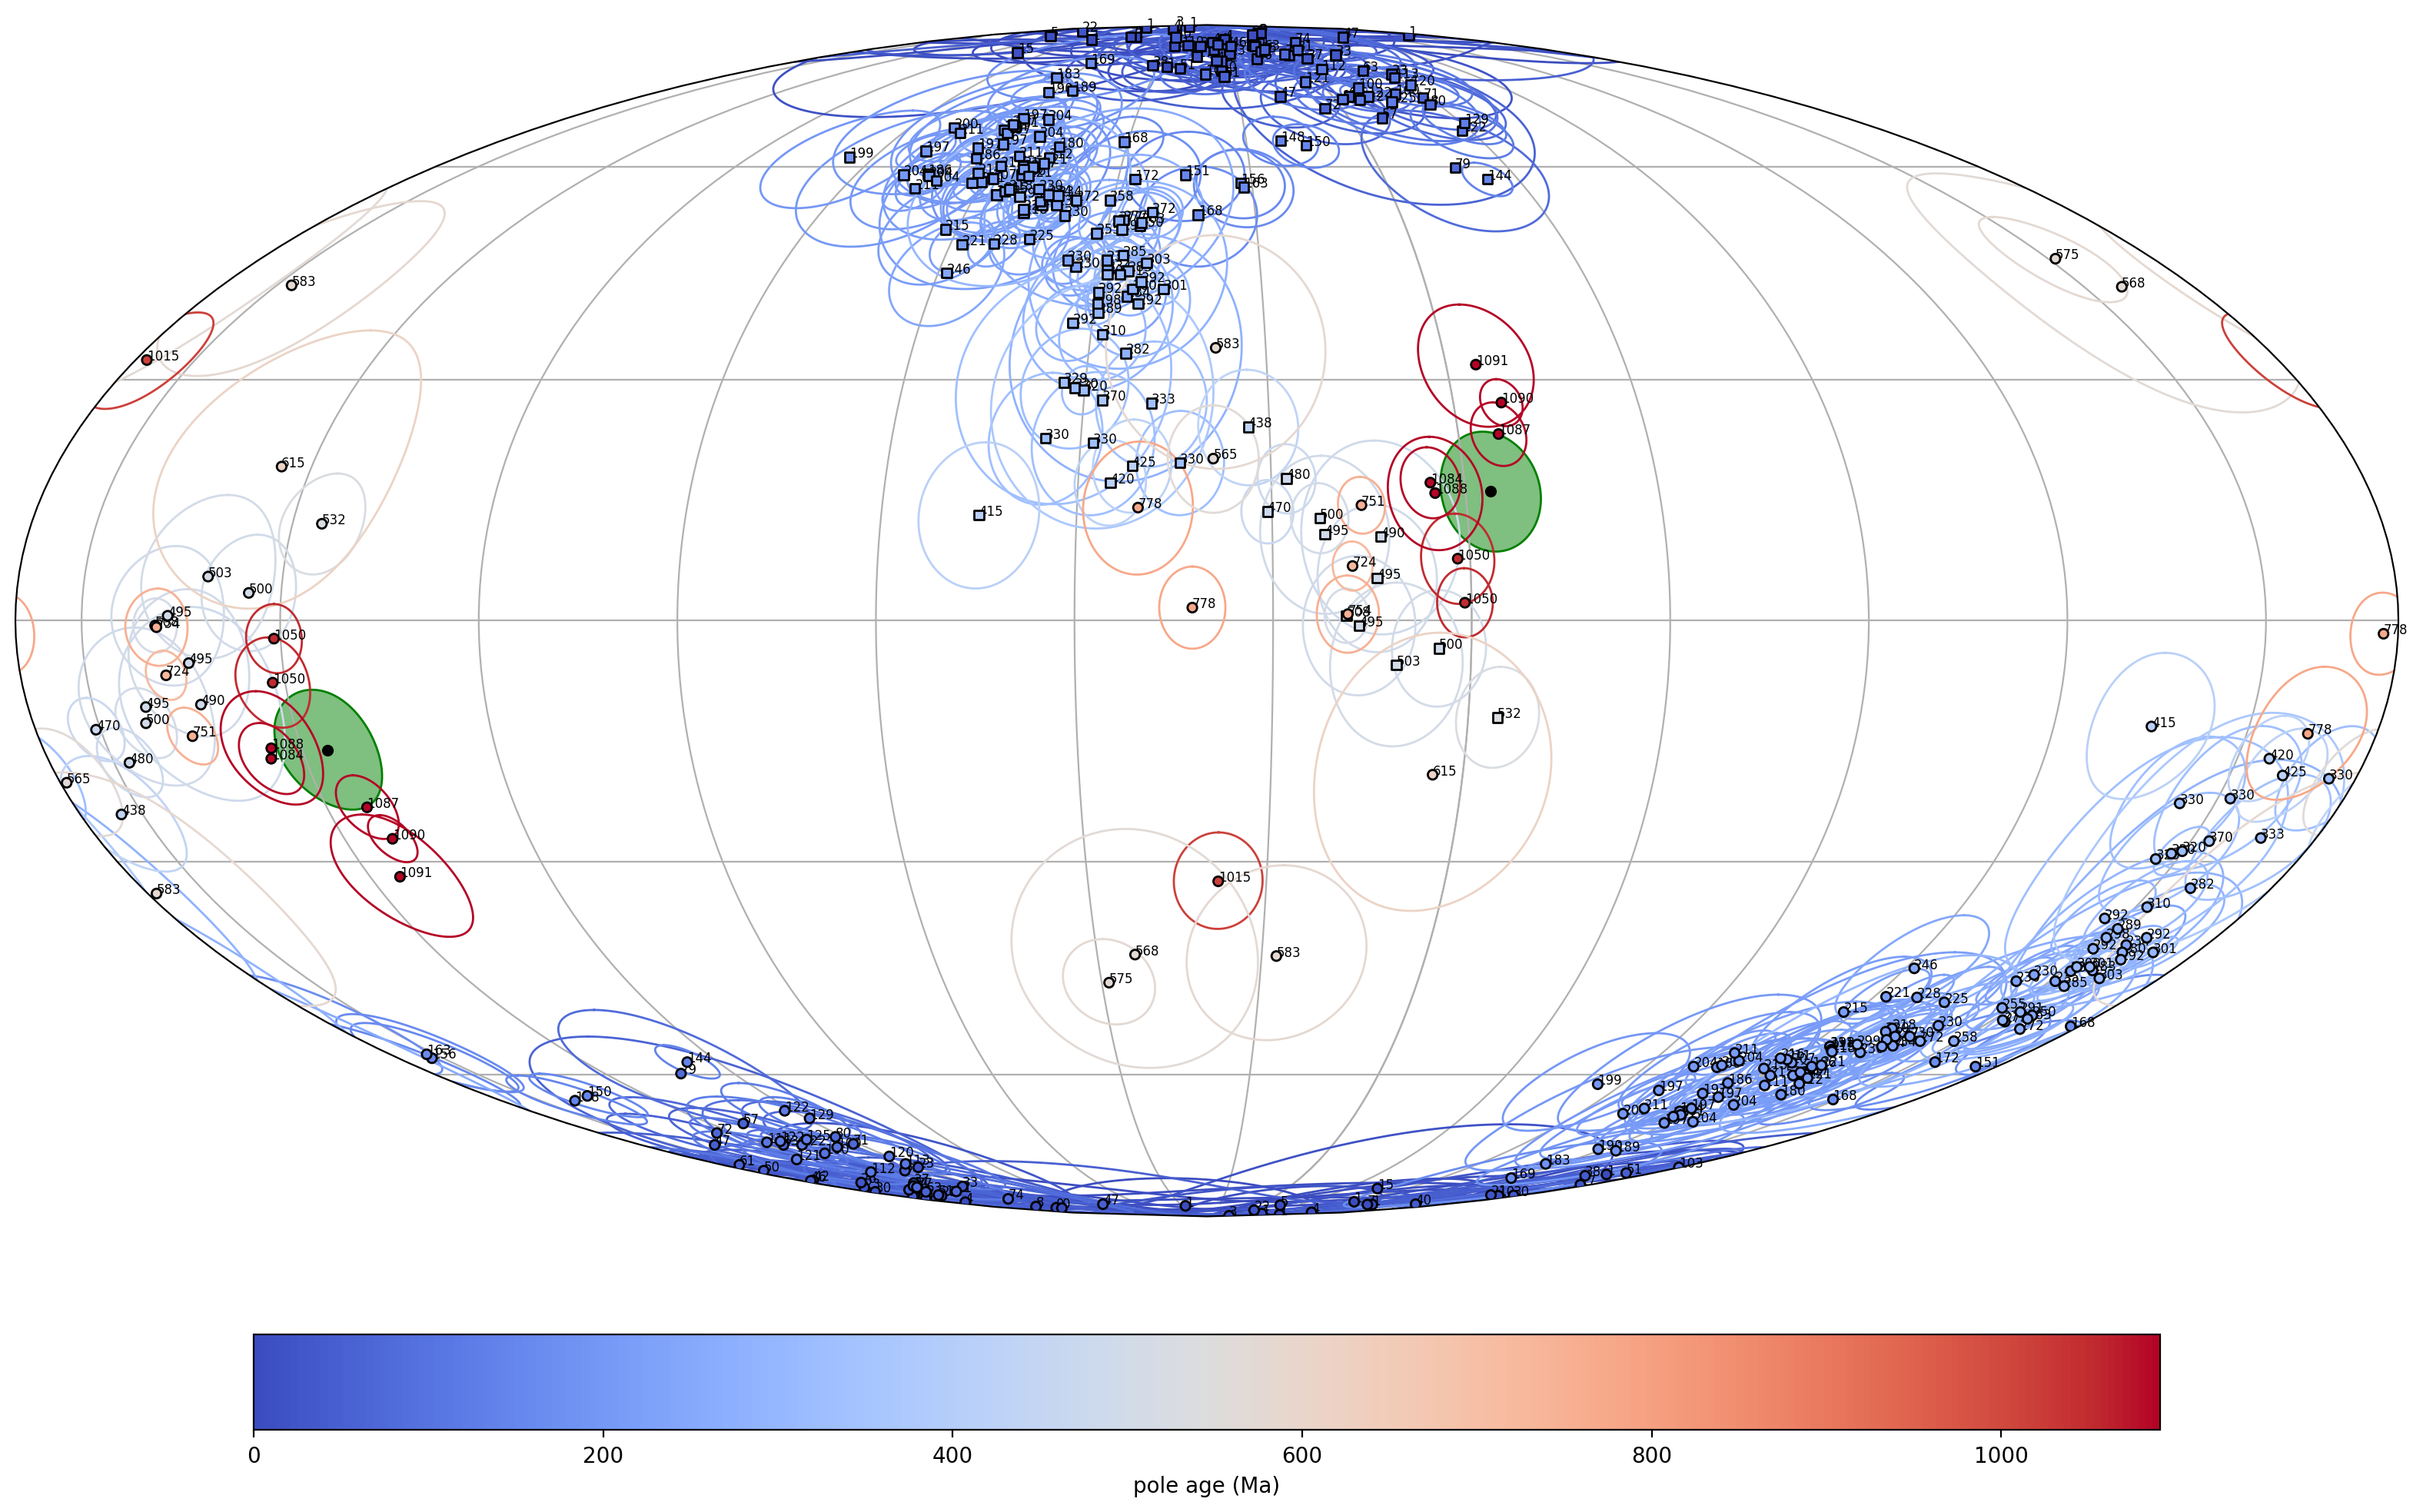

In [11]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Cardenas Basalts and Intrusions', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                  pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                  pole_A95=pole_mean['alpha95'])

### R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb CA-ID-TIMS zircon ages: 1082.18 ± 1.25 Ma (CB3); from Mohr et al. (2024). |
| 2 | Techniques and statistical analysis | **1** | (a) Only thermal demagnetization applied to all sites. (b) PCA used for component isolation. (c) N = more than 25 sites, k = 22.7, A95 = 7.4° passes Deenen et al. (2011) envelope (4.2°–15.6°). B = 18 sites ≥ 8. |
| 3 | Magnetic mineralogy characterized | **1** | Thermal demagnetization data is consistent with remanence being dominantly held by low-titanium magnetite and (titano) hematite. |
| 4 | Field tests constrain age of magnetization | **0** | No field tests available. |
| 5 | Structural control / tectonic coherence | **1** | Bedding orientations were taken from lava flows and nearby sedimentary rocks in the Unkar Group for tilt correcting directional data. Lava flows — no inclination shallowing correction needed. |
| 6 | Presence of reversals | **0** | All directions are of single polarity. No reversal test possible. |
| 7 | No resemblance to younger poles | **1** | The pole does not overlap with any known younger poles. |
| | **Total R-score** | **5/7** | |

# Nordic workshop ranking

Prior Nordic Workshop compilations of paleomagnetic poles with expert-assigned rankings (Evans et al., 2021) have given the pole from the Gunbarrel LIP a 'B' ranking. Our assessment is that with the work of Ding et al. (2025) that the revised pole can now be assigned 'A' ranking. There are two major advances with the work of Ding et al. (2025):
- Two positive baked contact tests published in their study: one from the Christmas Lake dike in the Beartooth Mountains of the Wyoming Craton and the other from the Hottah Lake (Calder) gabbro sheet of the Slave craton.
- Numerous additional VGPs from units that are associated with cratons rather than mobile belts combined with the informed exclusion of data from the Tobacco Root Mountains.



In [12]:
Cardenas_summary = pt.make_nordic_summary(terrane='Laurentia', 
                                        rockname='Cardenas Basalts', 
                                        sites=Cardenas_Basalt_all,
                                        dir_mean=dir_mean,
                                        pole_mean=pole_mean,
                                        study_lon=study_lon,
                                        study_lat=study_lat,
                                        component_comment='',
                                        tests='',
                                        f_factor=1,
                                        pole_mean_unflattened=None,
                                        R1=1,
                                        R2=1,
                                        R3=1,
                                        R4=0,
                                        R5=1,
                                        R6=0,
                                        R7=1,
                                        Grade='A',
                                        nominal_age=1082.18,
                                        lomagage=1080.93,
                                        himagage=1083.43,
                                        REF_method='U-Pb CA-ID-TIMS zircon age: 1082.18 ± 1.25 Ma;  from Mohr et al. (2024).',
                                        POLE_AUTHORS='Zhang, Y., Anderson, N. S., Mohr, M. T., Nelson, L. L., Macdonald, F. A., Schmitz, M. D., Thurston, O. G., Guenthner, W. R., Karlstrom, K. E., & Swanson-Hysell, N. L.',
                                        YEAR=2024,
                                        JOURNAL='Journal of Geophysical Research: Solid Earth',
                                        VOLUME=129,
                                        VPAGES='',
                                        TITLE='Paleomagnetic records from pulsed magmatism in the southwestern Laurentia large igneous province and Cardenas Basalt support rapid late Mesoproterozoic plate motion',
                                        COMMENT=''
                                        )
Cardenas_summary

{'terrane': 'Laurentia',
 'rockname': 'Cardenas Basalts',
 'component_comment': '',
 'tests': '',
 'tilt': 100,
 'study_lat': 36.283889,
 'study_lon': 248.108056,
 'site_n': 18,
 'sample_n': 141,
 'dir_dec_mean': 268.4703435405501,
 'dir_inc_mean': 46.398193263727876,
 'dir_inc_mean_abs': 46.398193263727876,
 'dir_k': 20.1568162849471,
 'dir_alpha_95': 7.892589195177538,
 'pole_lat': 183.9201365297194,
 'pole_lon': 15.934944694473888,
 'pole_dp': '',
 'pole_dm': '',
 'pole_A95': 7.415071700086885,
 'f_factor': 1,
 'inc_f': 46.39819326372788,
 'pole_lat_unflattened': 183.9201365297194,
 'pole_lon_unflattened': 15.934944694473888,
 'pole_dp_unflattened': '',
 'pole_dm_unflattened': '',
 'pole_A95_unflattened': 7.415071700086885,
 'R1': 1,
 'R2': 1,
 'R3': 1,
 'R4': 0,
 'R5': 1,
 'R6': 0,
 'R7': 1,
 'Grade': 'A',
 'nominal_age': 1082.18,
 'lomagage': 1080.93,
 'himagage': 1083.43,
 'REF_method': 'U-Pb CA-ID-TIMS zircon age: 1082.18 ± 1.25 Ma;  from Mohr et al. (2024).',
 'POLE_AUTHORS': '